Fraud Rate: 3.499%
Total Transactions: 590,540


Matplotlib is building the font cache; this may take a moment.


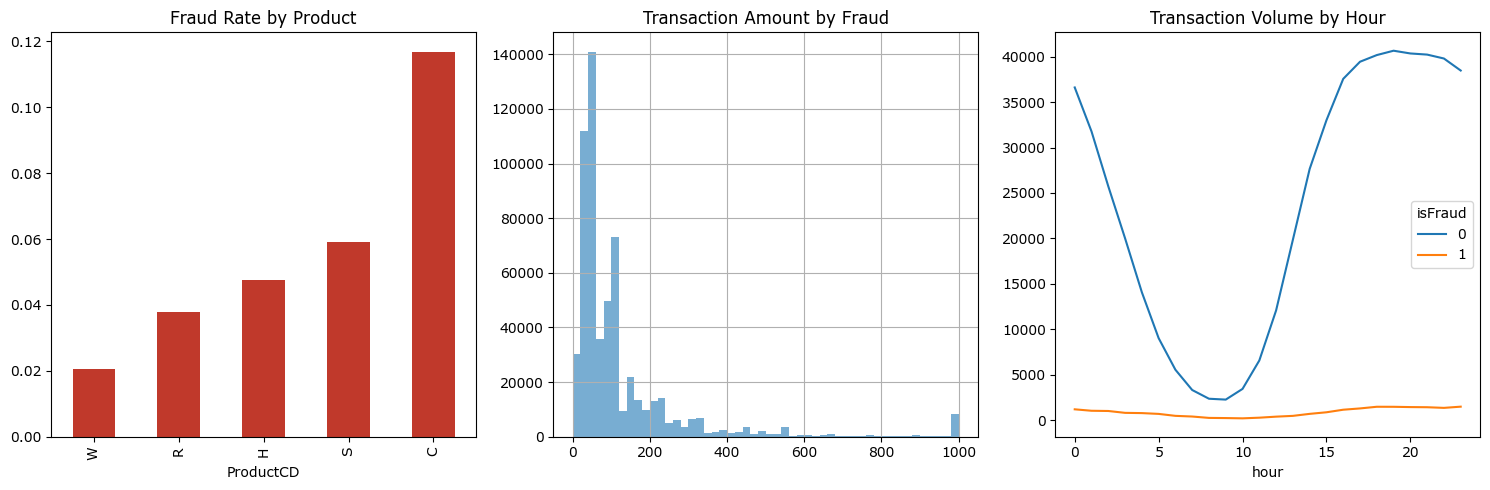

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

txn = pd.read_csv('../data/raw/train_transaction.csv')
idn = pd.read_csv('../data/raw/train_identity.csv')

# Merge datasets
df = txn.merge(idn, on='TransactionID', how='left')
print(f'Fraud Rate: {df["isFraud"].mean():.3%}')
print(f'Total Transactions: {len(df):,}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fraud rate by product
df.groupby('ProductCD')['isFraud'].mean().sort_values().plot(
    kind='bar', ax=axes[0], title='Fraud Rate by Product', color='#C0392B')

# Transaction amount distribution
df.groupby('isFraud')['TransactionAmt'].apply(lambda x: x.clip(0,1000)).hist(
    bins=50, ax=axes[1], alpha=0.6)
axes[1].set_title('Transaction Amount by Fraud')

# Transaction hour of day (fraud timing)
df['hour'] = (df['TransactionDT'] // 3600) % 24
df.groupby(['hour','isFraud'])['TransactionID'].count().unstack().plot(
    ax=axes[2], title='Transaction Volume by Hour')

plt.tight_layout()
plt.savefig('../reports/eda_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
